# CloudTrail 위협 탐지 모델 - Confusion Matrix 분석

훈련된 모델의 성능을 confusion matrix로 시각화하고 분석합니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import sys
import os

# src 디렉토리를 경로에 추가
sys.path.append('src')

from cloudtrail_threat_detector import CloudTrailThreatDetector
# 파일 기반 데이터 로더는 더 이상 지원하지 않음
# from data_loader import CloudTrailDataLoader

# 플롯 스타일 설정
plt.style.use('default')
sns.set_palette('husl')

print("라이브러리 로드 완료!")

## 1. 모델 로드

In [14]:
# 사용할 모델 경로 설정
model_path = "models/cloudTrail_v1.pkl"

# 모델 로드
detector = CloudTrailThreatDetector()

try:
    detector.load_model(model_path)
    print(f"✅ 모델 로드 성공: {model_path}")
    print(f"특성 개수: {len(detector.feature_names)}")
    print(f"훈련 상태: {detector.is_trained}")
except FileNotFoundError:
    print(f"❌ 모델 파일을 찾을 수 없습니다: {model_path}")
    print("사용 가능한 모델 파일:")
    for f in os.listdir("models"):
        if f.endswith(".pkl"):
            print(f"  - {f}")
except Exception as e:
    print(f"❌ 모델 로드 실패: {e}")

모델이 models/cloudTrail_v1.pkl에서 로드되었습니다
✅ 모델 로드 성공: models/cloudTrail_v1.pkl
특성 개수: 23
훈련 상태: True


## 2. 테스트 데이터 준비

실제 데이터가 있다면 경로를 수정하고, 없다면 샘플 데이터를 생성합니다.

In [ ]:
def generate_sample_test_data(n_samples=200):
    """테스트용 샘플 데이터 생성"""
    import random
    from datetime import datetime, timedelta
    
    sample_logs = []
    
    # 정상 로그 생성 (80%)
    normal_count = int(n_samples * 0.8)
    normal_events = ['ListBuckets', 'GetObject', 'DescribeInstances', 'GetUser', 'ListUsers']
    normal_sources = ['s3.amazonaws.com', 'ec2.amazonaws.com', 'iam.amazonaws.com']
    
    for i in range(normal_count):
        # 정상적인 시간대 (오전 9시 ~ 오후 6시)
        hour = random.randint(9, 18)
        event_time = datetime.now().replace(hour=hour, minute=random.randint(0, 59))
        
        log = {
            'eventTime': event_time.isoformat() + 'Z',
            'eventName': random.choice(normal_events),
            'eventSource': random.choice(normal_sources),
            'sourceIPAddress': f"192.168.1.{random.randint(1, 254)}",  # 내부 IP
            'userAgent': random.choice(['aws-console', 'aws-cli/2.1.34', 'Boto3/1.20.26']),
            'userIdentity': {
                'type': 'IAMUser',
                'userName': f'employee_{i:03d}'
            },
            'requestParameters': {
                'bucketName': f'company-data-{random.randint(1, 10)}'
            },
            'responseElements': {'x-amz-id-2': 'some-id'},
            'errorCode': None
        }
        sample_logs.append(log)
    
    # 위협 로그 생성 (20%)
    threat_count = n_samples - normal_count
    threat_tools = ['stratus-red-team', 'atomic-red-team', 'python-requests/2.25.1', 'boto3/1.20.26']
    threat_events = ['CreateUser', 'AttachUserPolicy', 'PutBucketPolicy', 'DeleteBucket', 'CreateAccessKey']
    
    for i in range(threat_count):
        # 심야 시간대 (밤 10시 ~ 새벽 6시)
        hour = random.choice(list(range(22, 24)) + list(range(0, 7)))
        event_time = datetime.now().replace(hour=hour, minute=random.randint(0, 59))
        
        log = {
            'eventTime': event_time.isoformat() + 'Z',
            'eventName': random.choice(threat_events),
            'eventSource': random.choice(normal_sources),
            'sourceIPAddress': f"203.0.113.{random.randint(1, 254)}",  # 외부 IP
            'userAgent': random.choice(threat_tools),
            'userIdentity': {
                'type': 'IAMUser',
                'userName': f'test-user-{i}' if random.random() > 0.5 else f'admin_{i}'
            },
            'requestParameters': {
                'bucketName': f'stratus-red-team-{i}' if random.random() > 0.5 else f'test-bucket-{i}'
            },
            'errorCode': random.choice(['AccessDenied', None, 'InvalidUserID.NotFound']),
            'responseElements': None if random.random() > 0.5 else {'x-amz-id-2': 'some-id'}
        }
        sample_logs.append(log)
    
    random.shuffle(sample_logs)
    return sample_logs

# 실제 테스트 데이터가 있다면 주석 해제하고 경로 수정
# test_data_path = "data/093342385579_CloudTrail_ap-northeast-2_20250813T0555Z_ZIOUpWo2hJGvALpY.json"
# 파일 기반 데이터 로더는 더 이상 지원하지 않음
# loader = CloudTrailDataLoader()
# test_logs = loader.load_from_json_file(test_data_path)
# test_logs = loader.validate_logs(test_logs)

# 샘플 데이터 사용
test_logs = generate_sample_test_data(300)
print(f"테스트 로그 개수: {len(test_logs)}")

## 3. 예측 수행 및 실제 라벨 생성

In [16]:
# 예측 및 실제 라벨 수집
y_true = []  # 실제 라벨 (규칙 기반)
y_pred = []  # 모델 예측
confidence_scores = []  # 신뢰도

print("예측 수행 중...")
for i, log in enumerate(test_logs):
    if i % 50 == 0:
        print(f"진행률: {i}/{len(test_logs)}")
    
    # 실제 라벨 (규칙 기반 라벨링)
    true_label = detector._create_rule_based_labels([log])[0]
    
    # 모델 예측
    result = detector.predict_with_confidence(log)
    pred_label = 1 if result['is_threat'] else 0
    confidence = result['confidence']
    
    y_true.append(true_label)
    y_pred.append(pred_label)
    confidence_scores.append(confidence)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
confidence_scores = np.array(confidence_scores)

print(f"\n예측 완료!")
print(f"실제 위협: {np.sum(y_true)}개 ({np.sum(y_true)/len(y_true)*100:.1f}%)")
print(f"예측 위협: {np.sum(y_pred)}개 ({np.sum(y_pred)/len(y_pred)*100:.1f}%)")

예측 수행 중...
진행률: 0/300
진행률: 50/300
진행률: 100/300
진행률: 150/300
진행률: 200/300
진행률: 250/300

예측 완료!
실제 위협: 223개 (74.3%)
예측 위협: 300개 (100.0%)


## 4. Confusion Matrix 시각화

In [20]:
# Confusion Matrix 계산
cm = confusion_matrix(y_true, y_pred)
accuracy = np.sum(np.diag(cm)) / np.sum(cm)

# 정밀도, 재현율, F1 점수 계산
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Confusion Matrix:")
print(f"  TN: {tn}, FP: {fp}")
print(f"  FN: {fn}, TP: {tp}")
print(f"\nPerformance Metrics:")
print(f"  Accuracy: {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall: {recall:.3f}")
print(f"  F1 Score: {f1:.3f}")

Confusion Matrix:
  TN: 0, FP: 77
  FN: 0, TP: 223

Performance Metrics:
  Accuracy: 0.743
  Precision: 0.743
  Recall: 1.000
  F1 Score: 0.853


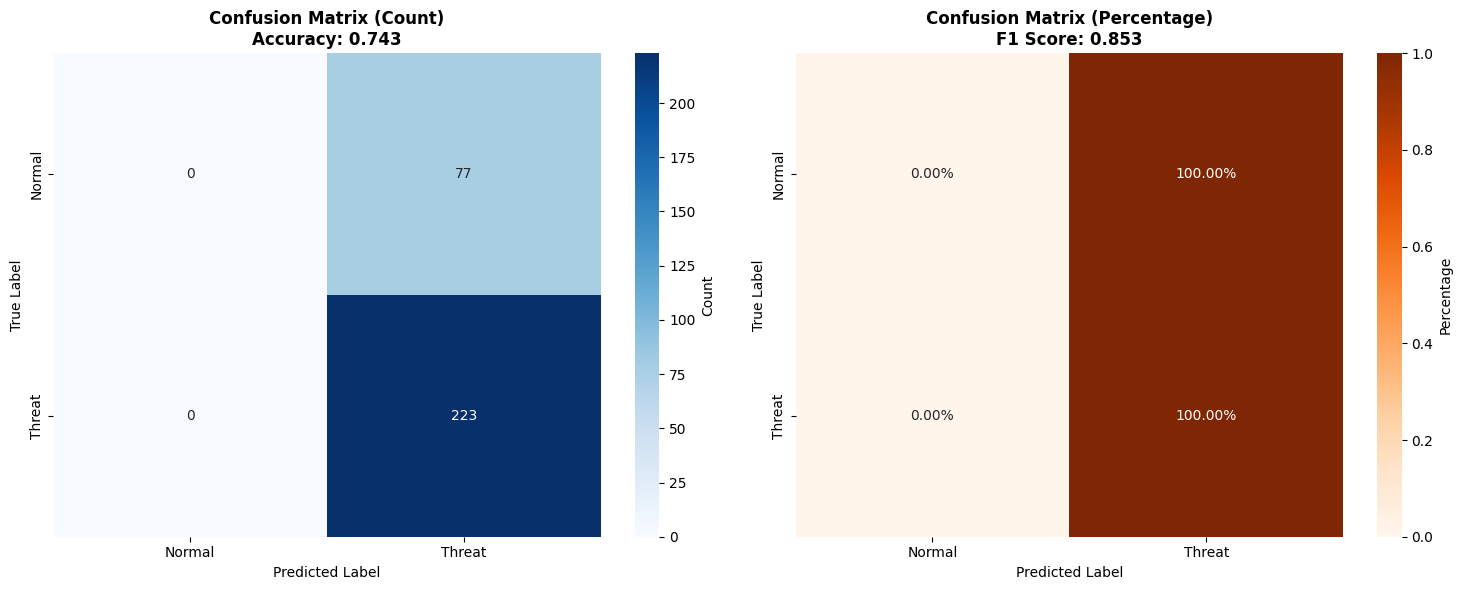

In [21]:
# Confusion Matrix 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 절대값 Confusion Matrix
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Normal', 'Threat'],
            yticklabels=['Normal', 'Threat'],
            ax=axes[0],
            cbar_kws={'label': 'Count'})

axes[0].set_title(f'Confusion Matrix (Count)\nAccuracy: {accuracy:.3f}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. 비율 Confusion Matrix
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_percent, 
            annot=True, 
            fmt='.2%', 
            cmap='Oranges',
            xticklabels=['Normal', 'Threat'],
            yticklabels=['Normal', 'Threat'],
            ax=axes[1],
            cbar_kws={'label': 'Percentage'})

axes[1].set_title(f'Confusion Matrix (Percentage)\nF1 Score: {f1:.3f}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## 5. 상세 분석

In [22]:
# 분류 보고서
print("=== Detailed Classification Report ===")
print(classification_report(y_true, y_pred, 
                          target_names=['Normal', 'Threat'],
                          digits=4))

=== Detailed Classification Report ===
              precision    recall  f1-score   support

      Normal     0.0000    0.0000    0.0000        77
      Threat     0.7433    1.0000    0.8528       223

    accuracy                         0.7433       300
   macro avg     0.3717    0.5000    0.4264       300
weighted avg     0.5525    0.7433    0.6339       300



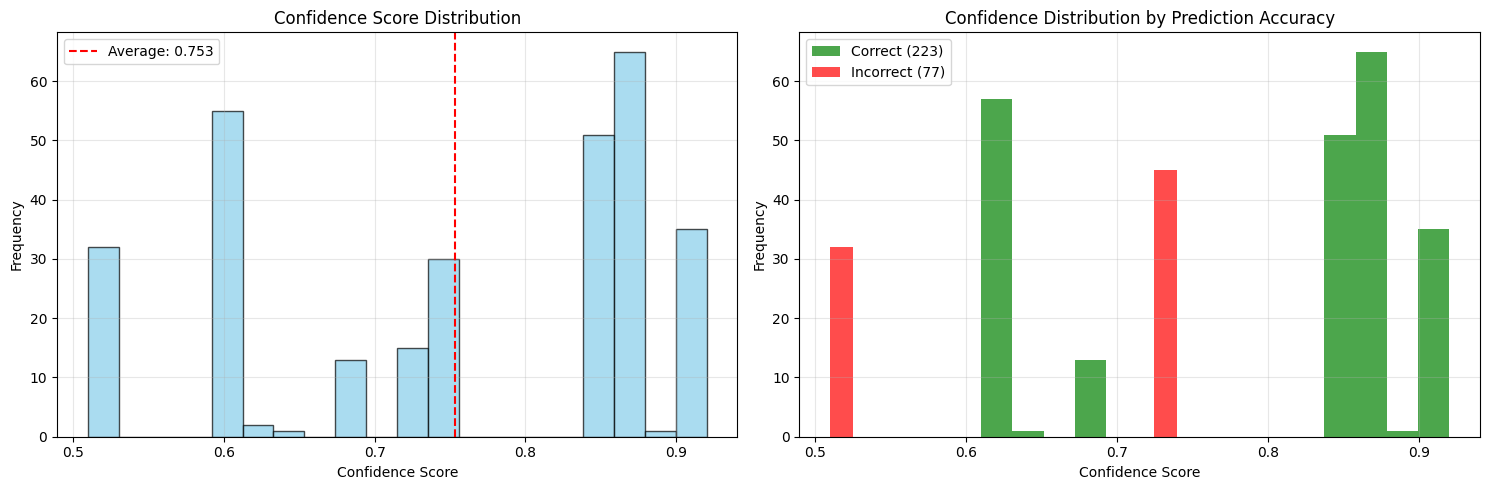

Average confidence of correct predictions: 0.791
Average confidence of incorrect predictions: 0.642


In [23]:
# 신뢰도 분포 분석
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. 전체 신뢰도 분포
axes[0].hist(confidence_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(confidence_scores.mean(), color='red', linestyle='--', 
                label=f'Average: {confidence_scores.mean():.3f}')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Confidence Score Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. 정답/오답별 신뢰도 분포
correct_predictions = (y_true == y_pred)
incorrect_predictions = ~correct_predictions

axes[1].hist(confidence_scores[correct_predictions], bins=15, alpha=0.7, 
             label=f'Correct ({np.sum(correct_predictions)})', color='green')
axes[1].hist(confidence_scores[incorrect_predictions], bins=15, alpha=0.7, 
             label=f'Incorrect ({np.sum(incorrect_predictions)})', color='red')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Confidence Distribution by Prediction Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average confidence of correct predictions: {confidence_scores[correct_predictions].mean():.3f}")
print(f"Average confidence of incorrect predictions: {confidence_scores[incorrect_predictions].mean():.3f}")

## 6. 오분류 사례 분석

In [24]:
# False Positive (정상인데 위협으로 분류) 분석
false_positives = (y_true == 0) & (y_pred == 1)
fp_indices = np.where(false_positives)[0]

print(f"=== False Positive 분석 ({len(fp_indices)}개) ===")
if len(fp_indices) > 0:
    print("상위 5개 False Positive 사례:")
    for i, idx in enumerate(fp_indices[:5]):
        log = test_logs[idx]
        conf = confidence_scores[idx]
        print(f"\n{i+1}. 신뢰도: {conf:.3f}")
        print(f"   이벤트: {log.get('eventName')} ({log.get('eventSource')})")
        print(f"   시간: {log.get('eventTime')}")
        print(f"   User Agent: {log.get('userAgent')}")
        print(f"   소스 IP: {log.get('sourceIPAddress')}")
else:
    print("False Positive 없음!")

=== False Positive 분석 (77개) ===
상위 5개 False Positive 사례:

1. 신뢰도: 0.740
   이벤트: GetUser (iam.amazonaws.com)
   시간: 2025-08-19T10:23:13.450325Z
   User Agent: aws-console
   소스 IP: 192.168.1.217

2. 신뢰도: 0.730
   이벤트: ListBuckets (s3.amazonaws.com)
   시간: 2025-08-19T16:50:13.450325Z
   User Agent: aws-console
   소스 IP: 192.168.1.221

3. 신뢰도: 0.510
   이벤트: DescribeInstances (ec2.amazonaws.com)
   시간: 2025-08-19T17:14:13.450325Z
   User Agent: aws-console
   소스 IP: 192.168.1.87

4. 신뢰도: 0.740
   이벤트: GetUser (iam.amazonaws.com)
   시간: 2025-08-19T13:26:13.450325Z
   User Agent: aws-console
   소스 IP: 192.168.1.66

5. 신뢰도: 0.740
   이벤트: DescribeInstances (iam.amazonaws.com)
   시간: 2025-08-19T13:04:13.448970Z
   User Agent: aws-console
   소스 IP: 192.168.1.193


In [25]:
# False Negative (위협인데 정상으로 분류) 분석
false_negatives = (y_true == 1) & (y_pred == 0)
fn_indices = np.where(false_negatives)[0]

print(f"=== False Negative 분석 ({len(fn_indices)}개) ===")
if len(fn_indices) > 0:
    print("상위 5개 False Negative 사례:")
    for i, idx in enumerate(fn_indices[:5]):
        log = test_logs[idx]
        conf = confidence_scores[idx]
        print(f"\n{i+1}. 신뢰도: {conf:.3f}")
        print(f"   이벤트: {log.get('eventName')} ({log.get('eventSource')})")
        print(f"   시간: {log.get('eventTime')}")
        print(f"   User Agent: {log.get('userAgent')}")
        print(f"   소스 IP: {log.get('sourceIPAddress')}")
else:
    print("False Negative 없음!")

=== False Negative 분석 (0개) ===
False Negative 없음!


## 7. 특성 중요도 분석

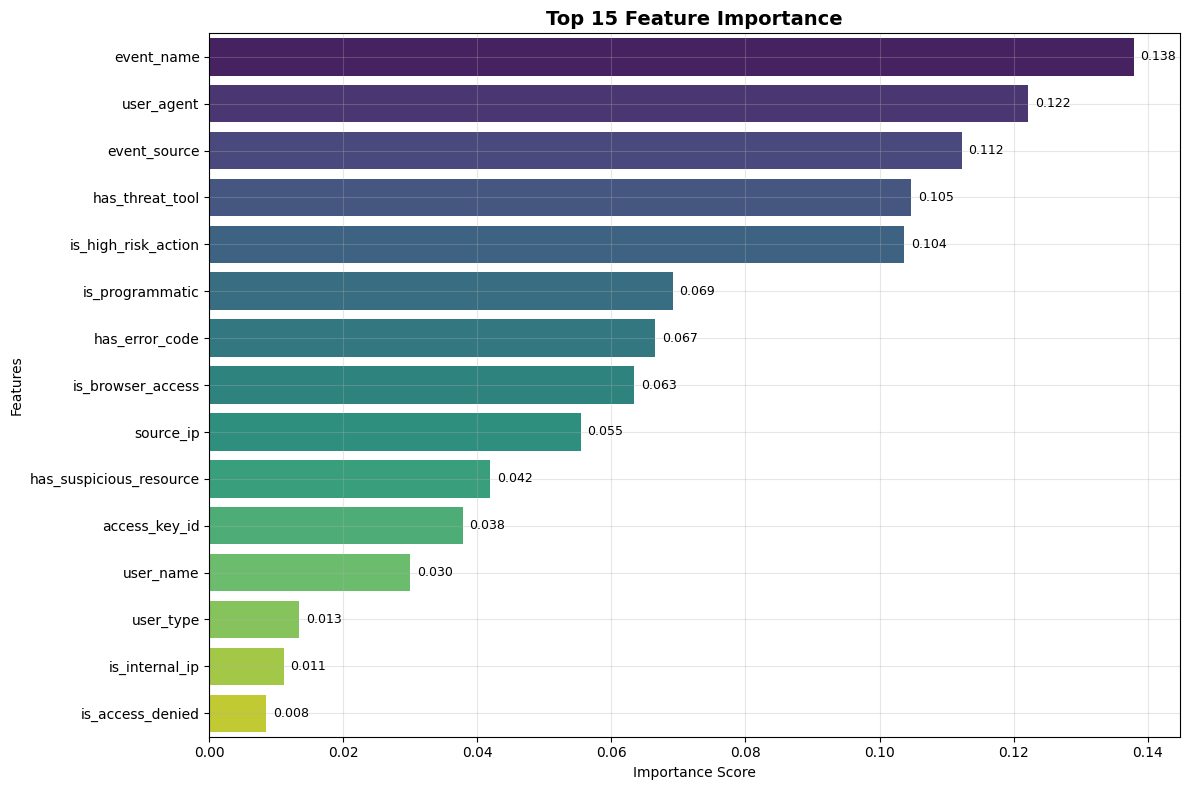


Top 10 Feature Importance:
 1. event_name: 0.1379
 2. user_agent: 0.1222
 3. event_source: 0.1123
 4. has_threat_tool: 0.1047
 5. is_high_risk_action: 0.1037
 6. is_programmatic: 0.0691
 7. has_error_code: 0.0666
 8. is_browser_access: 0.0634
 9. source_ip: 0.0554
10. has_suspicious_resource: 0.0419


In [26]:
# 특성 중요도 시각화
if hasattr(detector, 'feature_importance_') and detector.feature_importance_ is not None:
    feature_imp = detector.feature_importance_.head(15)  # 상위 15개
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_imp, y='feature', x='importance', palette='viridis')
    plt.title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.grid(True, alpha=0.3)
    
    # 중요도 값 표시
    for i, (idx, row) in enumerate(feature_imp.iterrows()):
        plt.text(row['importance'] + 0.001, i, f'{row["importance"]:.3f}', 
                va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Feature Importance:")
    for i, (idx, row) in enumerate(feature_imp.head(10).iterrows(), 1):
        print(f"{i:2d}. {row['feature']}: {row['importance']:.4f}")
else:
    print("Feature importance information not available.")

## 8. 결론 및 요약

In [27]:
print("=" * 60)
print("Model Performance Summary")
print("=" * 60)
print(f"Test dataset size: {len(test_logs)} logs")
print(f"Actual Threat/Normal ratio: {np.sum(y_true)}/{len(y_true)-np.sum(y_true)} ({np.sum(y_true)/len(y_true)*100:.1f}%/{(len(y_true)-np.sum(y_true))/len(y_true)*100:.1f}%)")
print()
print(f"🎯 Accuracy: {accuracy:.3f}")
print(f"🔍 Precision: {precision:.3f}")
print(f"📊 Recall: {recall:.3f}")
print(f"⚖️  F1 Score: {f1:.3f}")
print()
print(f"Misclassification Analysis:")
print(f"  False Positive: {fp} (Normal classified as Threat)")
print(f"  False Negative: {fn} (Threat classified as Normal)")
print()
print(f"Average confidence: {confidence_scores.mean():.3f}")
print(f"Confidence std deviation: {confidence_scores.std():.3f}")

Model Performance Summary
Test dataset size: 300 logs
Actual Threat/Normal ratio: 223/77 (74.3%/25.7%)

🎯 Accuracy: 0.743
🔍 Precision: 0.743
📊 Recall: 1.000
⚖️  F1 Score: 0.853

Misclassification Analysis:
  False Positive: 77 (Normal classified as Threat)
  False Negative: 0 (Threat classified as Normal)

Average confidence: 0.753
Confidence std deviation: 0.133
